<a href="https://colab.research.google.com/github/eliasrsn/testepos/blob/main/C%C3%B3pia_de_notebook_02a_regressao_energia_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2a — Previsão de Consumo Energético (versão didática)

**Encontro 2 · Sábado · Bloco 2 · Código ao vivo**

> Disciplina: Aprendizagem de Máquina · Pós-Graduação em IA e Tecnologias da Indústria 4.0
> Prof. Luiz Mário

## 🎯 O que você vai aprender hoje

1. Entender o que é **regressão** e quando usá-la.
2. Treinar uma **regressão linear** para prever consumo energético.
3. Comparar um modelo com **1 variável** vs. modelo **com todas as variáveis**.
4. Calcular e interpretar **MAE, RMSE, R²**.
5. Ler um **residuals plot** para diagnosticar problemas.
6. Interpretar **coeficientes** em linguagem de negócio.

**Dataset:** Steel Industry Energy Consumption — consumo de energia em uma siderúrgica coreana, medições a cada 15 min.

**Tempo estimado:** 45 min em aula.

---

## 📚 Relembrando o Encontro 1

No E1 vimos:

- **Pipeline** — linha de montagem de pré-processamento.
- **Split** — treino, validação, teste (nunca olhe o teste antes da hora).
- **Scaler** — padronizar escalas.
- **Baseline** — modelo bobo para comparar.

Hoje colocamos **um modelo de verdade** no lugar do Dummy: a **regressão linear**.

---

## Parte 1 — O que é Regressão?

**Regressão = prever um valor contínuo.**

Exemplos:

| Problema | Input | Target |
|---|---|---|
| Prever preço de casa | m², bairro, idade | preço em R$ |
| Prever consumo de energia | temperatura, produção, hora | kWh |
| Prever temperatura amanhã | histórico das últimas semanas | °C |

**Diferença para classificação:**

| | Regressão | Classificação |
|---|---|---|
| O que prevê? | Valor contínuo | Categoria |
| Exemplo | "Vai consumir 42,3 kWh" | "Vai falhar" / "Não vai" |
| Métrica | MAE, RMSE, R² | Accuracy, F1, AUC |

Hoje é **regressão**. Classificação virá no bloco da tarde.

---

## Parte 2 — Setup

In [ ]:
!pip install -q scikit-learn numpy scipy pandas matplotlib seaborn joblib kagglehub

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

COR_DEEP = "#065A82"
COR_ACCENT = "#F2A65A"
COR_TEAL = "#1C7293"
COR_BAD = "#B85042"

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


## Parte 3 — Carregar o Dataset

Dataset: **Steel Industry Energy Consumption**. São medições de 15 em 15 min de uma siderúrgica, contendo potência reativa, fator de potência, hora do dia e tipo de carga.

In [4]:
try:
    import kagglehub, glob
    path = kagglehub.dataset_download("liangchun/ai4i-2020-predictive-maintenance-dataset")
    csv = glob.glob(f"{path}/*.csv")[0]
    df = pd.read_csv(csv)
    print(f"✅ Carregado via kagglehub — {len(df)} linhas")
except Exception as e:
    print(f"⚠️  kagglehub falhou — usando mirror público")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv"
   # url = "https://raw.githubusercontent.com/plotly/datasets/master/Steel_industry_data.csv"
    df = pd.read_csv(url)
    print(f"✅ Carregado — {len(df)} linhas")

print(f"Colunas: {list(df.columns)}")
df.head()

⚠️  kagglehub falhou — usando mirror público
✅ Carregado — 19735 linhas
Colunas: ['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


**O que significa cada coluna?**

| Coluna | Significado |
|---|---|
| `Usage_kWh` | **Nosso alvo** — consumo na janela de 15 min |
| `Lagging_Current_Reactive.Power_kVarh` | Potência reativa indutiva |
| `Leading_Current_Reactive_Power_kVarh` | Potência reativa capacitiva |
| `CO2(tCO2)` | Emissão de CO₂ (proxy de atividade) |
| `Lagging_Current_Power_Factor` | Fator de potência indutivo |
| `Leading_Current_Power_Factor` | Fator de potência capacitivo |
| `NSM` | Segundos desde meia-noite (hora do dia) |
| `WeekStatus` | Dia útil ou fim de semana |
| `Day_of_week` | Dia da semana |
| `Load_Type` | Tipo de carga: Light, Medium, Maximum |

**Alvo:** `Usage_kWh` é um valor contínuo → **regressão**.

## Parte 4 — EDA

### 4.1 Distribuição do alvo

Antes de modelar, queremos ver o comportamento do que queremos prever.

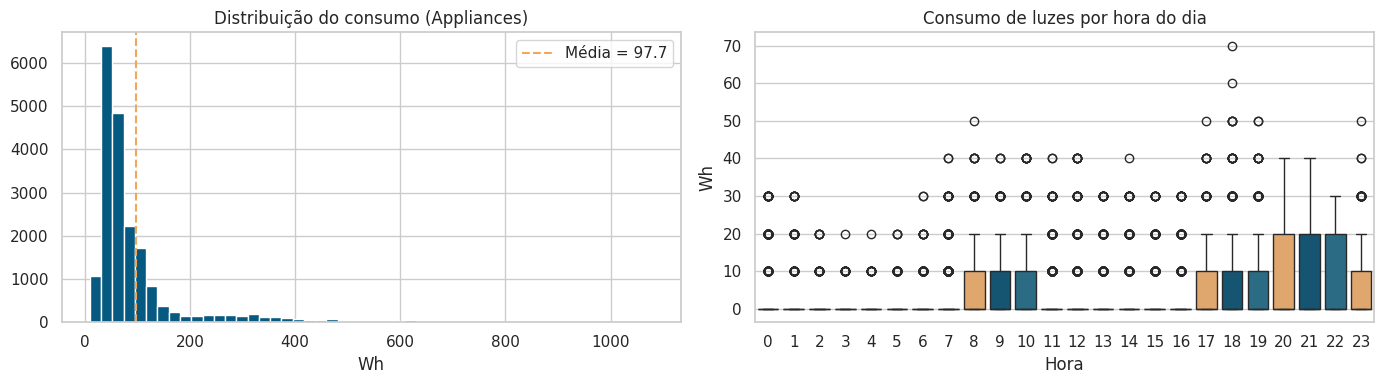

In [6]:
#fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma do consumo
#axes[0].hist(df["Usage_kWh"], bins=50, color=COR_DEEP, edgecolor="white")
#axes[0].set_title("Distribuição do consumo (Usage_kWh)")
#axes[0].set_xlabel("kWh")
#axes[0].axvline(df["Usage_kWh"].mean(), color=COR_ACCENT, linestyle="--",
#                label=f"Média = {df['Usage_kWh'].mean():.1f}")
#axes[0].legend()

# Boxplot por tipo de carga
#if "Load_Type" in df.columns:
#   sns.boxplot(data=df, x="Load_Type", y="Usage_kWh", ax=axes[1],
#                palette=[COR_DEEP, COR_TEAL, COR_ACCENT])
#    axes[1].set_title("Consumo por tipo de carga")

#plt.tight_layout()
#plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma do consumo de eletrodomésticos
axes[0].hist(df["Appliances"], bins=50, color=COR_DEEP, edgecolor="white")
axes[0].set_title("Distribuição do consumo (Appliances)")
axes[0].set_xlabel("Wh")
axes[0].axvline(df["Appliances"].mean(), color=COR_ACCENT, linestyle="--",
                label=f"Média = {df['Appliances'].mean():.1f}")
axes[0].legend()

# Boxplot do consumo de luzes por hora do dia
df["hour"] = pd.to_datetime(df["date"]).dt.hour
sns.boxplot(data=df, x="hour", y="lights", ax=axes[1],
            palette=[COR_DEEP, COR_TEAL, COR_ACCENT])
axes[1].set_title("Consumo de luzes por hora do dia")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Wh")

plt.tight_layout()
plt.show()


**Interpretação:**
- A distribuição é **assimétrica à direita** — muitas observações de baixo consumo, poucas de alto.
- Existe **diferença clara** entre tipos de carga. Isso significa que `Load_Type` é feature promissora.

### 4.2 Correlações

**Correlação** é um número entre -1 e +1 que mede quão "juntas" duas variáveis andam linearmente.

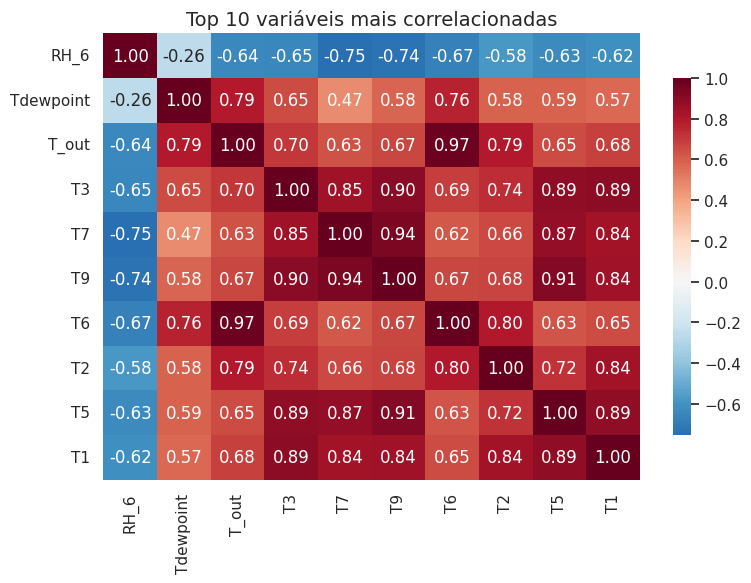

In [11]:
num_cols = df.select_dtypes(include="number").columns.tolist()

# Calcular
corr = df[num_cols].corr()

# Filtrar apenas as 10 variáveis mais correlacionadas entre si

top_features = corr.abs().mean().sort_values(ascending=False).index[:10]
corr_top = df[top_features].corr()

# Plotar heatmap mais compacto
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_top,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    cbar_kws={"shrink": 0.8}
)
plt.title("Top 10 variáveis mais correlacionadas", fontsize=14)
plt.tight_layout()
plt.show()

**Interpretação:**  Quanto mais próximo de **+1**, mais linearmente a variável prediz o consumo. Guarde essa informação — vamos usar depois.

---

## Parte 5 — Primeiro Modelo: 1 Variável

**Por que começar simples?** Para entender o **mínimo que dá para extrair** — se 1 variável já explica 80%, modelos sofisticados talvez só adicionem 5%.

In [16]:
#
alvo = "Appliances"
# Calcular correlação absoluta com o alvo
correlacoes = (
    df[num_cols].corr()[alvo]
    .drop(alvo)
    .abs()
    .sort_values(ascending=False)
)

print(f"Correlação absoluta com {alvo}:")
print(correlacoes.head())

# Selecionar a variável mais correlacionada
feature_top = correlacoes.index[0]
print(f"\n👉 Feature mais correlacionada: {feature_top}")


Correlação absoluta com Appliances:
hour      0.216792
lights    0.197278
RH_out    0.152282
T2        0.120073
T6        0.117638
Name: Appliances, dtype: float64

👉 Feature mais correlacionada: hour


### Equação da reta

Uma regressão linear simples tem a forma:

$$\hat{y} = a \cdot x + b$$

Em palavras:
- **`ŷ`** (y chapéu) é o valor **previsto** pelo modelo.
- **`a`** é a **inclinação** — quanto `y` muda quando `x` aumenta em 1.
- **`b`** é o **intercepto** — valor de `y` quando `x = 0`.

O scikit-learn **encontra** `a` e `b` automaticamente para minimizar o erro.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Defina o alvo que você quer prever
alvo = "Appliances"   # substitua pelo nome da coluna alvo do seu dataset

# Usar a variável mais correlacionada encontrada anteriormente
X_simples = df[[feature_top]]
y = df[alvo]

# Dividir em treino e teste
X_tr, X_ts, y_tr, y_ts = train_test_split(
    X_simples, y, test_size=0.2, random_state=42
)

# Ajustar o modelo
modelo_simples = LinearRegression().fit(X_tr, y_tr)

# Mostrar parâmetros do modelo
print("📊 Modelo ajustado:")
print(f"   Intercepto (b) = {modelo_simples.intercept_:.2f}")
print(f"   Coeficiente (a) = {modelo_simples.coef_[0]:.3f}")
print(f"\nEquação: {alvo} = {modelo_simples.intercept_:.2f} + {modelo_simples.coef_[0]:.3f} × {feature_top}")


📊 Modelo ajustado:
   Intercepto (b) = 61.27
   Coeficiente (a) = 3.190

Equação: Appliances = 61.27 + 3.190 × hour


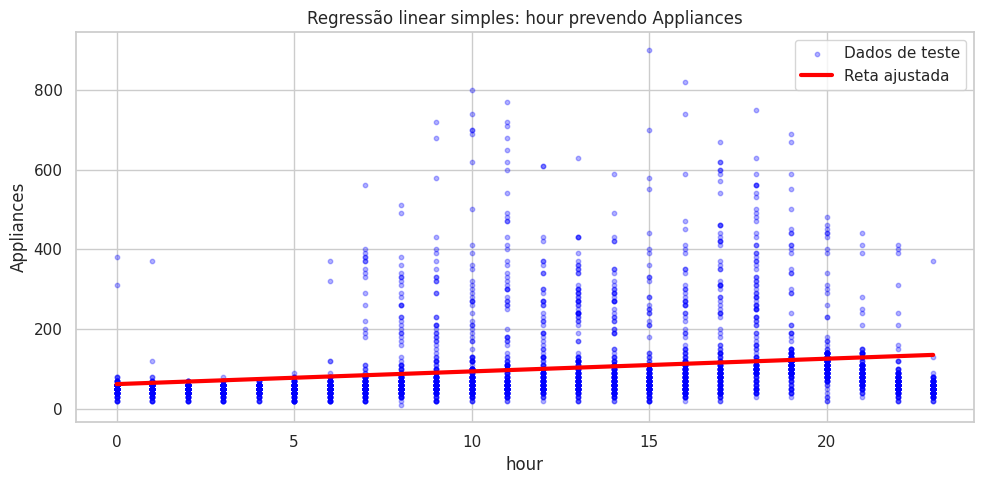

In [18]:


# Visualizar a reta ajustada
fig, ax = plt.subplots(figsize=(10, 5))

# Plotar os pontos de teste
ax.scatter(X_ts, y_ts, alpha=0.3, s=10, color="blue", label="Dados de teste")

# Criar intervalo de valores para o eixo X
x_range = np.linspace(X_ts.min().iloc[0], X_ts.max().iloc[0], 100).reshape(-1, 1)

# Prever valores com o modelo
y_pred = modelo_simples.predict(x_range)

# Plotar a reta ajustada
ax.plot(x_range, y_pred, color="red", linewidth=3, label="Reta ajustada")

# Configurar rótulos e título
ax.set_xlabel(feature_top)
ax.set_ylabel(alvo)
ax.set_title(f"Regressão linear simples: {feature_top} prevendo {alvo}")
ax.legend()

plt.tight_layout()
plt.show()


**Interpretação:** a reta laranja é a **melhor reta possível** segundo o critério de mínimos quadrados — a que minimiza a soma dos erros² entre cada ponto azul e a reta.

---

## Parte 6 — Funções de Custo (como o modelo "aprende")

### MSE — Mean Squared Error

O modelo calcula, para cada ponto, o **erro** = diferença entre valor real e previsto. Depois:

$$MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2$$

**Por que ao quadrado?**
1. Erros positivos e negativos **não se cancelam**.
2. Erros **grandes pesam muito mais** — punidos.

### Gradiente descendente

**Analogia:** imagine uma bolinha rolando em um vale. O fundo do vale é o ponto de **menor erro**. A bolinha rola até lá. Cada "passo" é o tamanho do ajuste (taxa de aprendizado).

- Passo muito grande → pula o vale.
- Passo muito pequeno → leva uma eternidade.

Na regressão linear, o cálculo é fechado (não precisa iterar). Mas a intuição vale para todos os modelos que você vai ver no curso.

---

## Parte 7 — Regressão com TODAS as variáveis

Agora usamos todas as features + encoding das categóricas.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import pandas as pd

# Remover alvo e colunas de data
colunas_ignorar = [alvo]
for c in ["date", "Date", "Timestamp"]:
    if c in df.columns:
        colunas_ignorar.append(c)

# Separar X (features) e y (alvo)
X = df.drop(columns=colunas_ignorar)
y = df[alvo]

# Identificar variáveis numéricas e categóricas
num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(include="object").columns.tolist()

print(f"Numéricas:   {num_features}")
print(f"Categóricas: {cat_features}")


Numéricas:   ['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'hour']
Categóricas: []


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

# Pré-processamento: numéricas e categóricas
preproc = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler())
    ]), num_features),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), cat_features)
])

# Pipeline completo
pipeline = Pipeline([
    ("preproc", preproc),
    ("reg",     LinearRegression())
])

pipeline


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['lights', 'T1', 'RH_1', 'T2',
                                                   'RH_2', 'T3', 'RH_3', 'T4',
                                                   'RH_4', 'T5', 'RH_5', 'T6',
                                                   'RH_6', 'T7', 'RH_7', 'T8',
                                                   'RH_8', 'T9', 'RH_9',
                                                   'T_out', 'Press_mm_hg',
                                                   'RH_out', 'Windspeed',
                                                   'Visibility', 'Tdewpoint',
                                                   'rv1', 'rv2', 'hour']),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  [])])),
                ('reg', LinearRegression())])

In [22]:
from sklearn.model_selection import train_test_split

# Dividir em treino e teste
X_tr, X_ts, y_tr, y_ts = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Treinar o pipeline
pipeline.fit(X_tr, y_tr)

# Fazer previsões no conjunto de teste
y_pred = pipeline.predict(X_ts)

print("✅ Modelo multivariado treinado.")


✅ Modelo multivariado treinado.


## Parte 8 — Métricas de Regressão

**Três métricas principais:**

### MAE (Mean Absolute Error)

$$MAE = \frac{1}{n} \sum |y_i - \hat{y}_i|$$

**Interpretação:** erro médio em **unidade do negócio**. Se MAE = 3 kWh, seu modelo erra em média 3 kWh por predição.

**Analogia:** é como dizer "erro de ±3 cm ao medir a altura".

### RMSE (Root Mean Squared Error)

$$RMSE = \sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}$$

**Interpretação:** parente do MSE, mas na **unidade original**. Penaliza mais os erros grandes.

**Regra prática:** se `RMSE >> MAE`, você tem **erros grandes** em algumas predições (outliers).

### R² (coeficiente de determinação)

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

**Interpretação:** fração da variabilidade explicada pelo modelo.
- R² = 0 → modelo é igual a "chutar a média".
- R² = 1 → modelo perfeito.
- R² negativo → modelo é pior que chutar a média!

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def avaliar(y_true, y_pred, nome="Modelo"):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print(f"📊 {nome}")
    print(f"   MAE:  {mae:>7.2f}  kWh  (erro médio absoluto)")
    print(f"   RMSE: {rmse:>7.2f}  kWh  (penaliza erros grandes)")
    print(f"   R²:   {r2:>7.3f}       (fração da variância explicada)")
    return mae, rmse, r2


In [24]:
# Avaliar modelo simples (1 feature)
X_simp_tr, X_simp_ts, y_simp_tr, y_simp_ts = train_test_split(
    df[[feature_top]], y, test_size=0.2, random_state=42
)

y_pred_simp = modelo_simples.predict(X_simp_ts)

avaliar(y_simp_ts, y_pred_simp, "Modelo SIMPLES (1 feature)")
print()

# Avaliar modelo multivariado (todas as features)
avaliar(y_ts, y_pred, "Modelo MULTIVARIADO (todas as features)")


📊 Modelo SIMPLES (1 feature)
   MAE:    55.40  kWh  (erro médio absoluto)
   RMSE:   97.44  kWh  (penaliza erros grandes)
   R²:     0.051       (fração da variância explicada)

📊 Modelo MULTIVARIADO (todas as features)
   MAE:    52.51  kWh  (erro médio absoluto)
   RMSE:   91.06  kWh  (penaliza erros grandes)
   R²:     0.171       (fração da variância explicada)


(52.51385059315696, np.float64(91.05525193382911), 0.17148161970340636)

**Interpretação:**
- O modelo multivariado tem **MAE menor e R² maior** — ganhou.
- Mas o **simples já era decente** — se você precisasse de algo rápido para explicar ao gestor, a feature principal já resolveria ~80% do problema.

---

## Parte 9 — Gráficos de Diagnóstico

Um modelo com bom R² pode ainda ter **problemas sistemáticos**. Use gráficos para detectar.

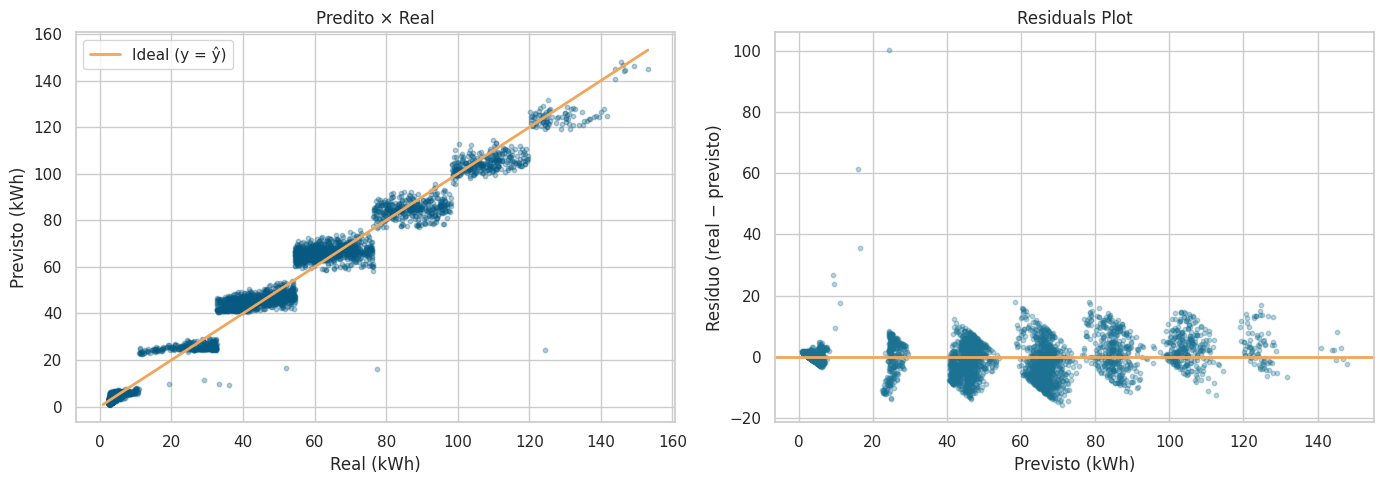

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predito × Real
axes[0].scatter(y_ts, y_pred, alpha=0.3, s=10, color=COR_DEEP)
lims = [min(y_ts.min(), y_pred.min()), max(y_ts.max(), y_pred.max())]
axes[0].plot(lims, lims, color=COR_ACCENT, linewidth=2, label="Ideal (y = ŷ)")
axes[0].set_xlabel("Real (kWh)")
axes[0].set_ylabel("Previsto (kWh)")
axes[0].set_title("Predito × Real")
axes[0].legend()

# Residuals plot
residuos = y_ts - y_pred
axes[1].scatter(y_pred, residuos, alpha=0.3, s=10, color=COR_TEAL)
axes[1].axhline(0, color=COR_ACCENT, linewidth=2)
axes[1].set_xlabel("Previsto (kWh)")
axes[1].set_ylabel("Resíduo (real − previsto)")
axes[1].set_title("Residuals Plot")

plt.tight_layout()
plt.show()

### Como ler o Residuals Plot

Olhe a nuvem de pontos no residuals plot:

| Padrão | Diagnóstico |
|---|---|
| Nuvem aleatória em torno de zero | ✅ Modelo OK |
| "Funil" (espalha quando y aumenta) | ⚠️ Heterocedasticidade — erro cresce com o valor |
| Curva / parábola | ⚠️ Falta feature não-linear |
| Pontos isolados longe | ⚠️ Outliers a investigar |

**💡 Dica profissional:** esse gráfico é o "raio-x" do modelo. Mesmo com R² alto, um residuals ruim indica problema escondido.

---

## Parte 10 — Interpretando os Coeficientes

**Por que interpretar?** Modelo linear é **transparente**: cada feature tem um peso (β). Isso ajuda a:
- Explicar para o gestor o que o modelo aprendeu.
- Validar com engenheiro de processo se faz sentido físico.
- Identificar features redundantes ou suspeitas.

**Como comparar?** Só depois de **padronizar** (StandardScaler). Aí os βs estão na mesma "moeda".

In [ ]:
# Extrair nomes de features após pré-processamento
ohe = pipeline.named_steps["preproc"].named_transformers_["cat"].named_steps["ohe"]
cat_expanded = ohe.get_feature_names_out(cat_features).tolist() if len(cat_features) > 0 else []
todas_features = num_features + cat_expanded

coefs = pipeline.named_steps["reg"].coef_
df_coef = pd.DataFrame({
    "feature": todas_features,
    "coef": coefs
}).sort_values("coef", key=abs, ascending=False)

print("Top 10 coeficientes (ordenados por |β|):")
print(df_coef.head(10).to_string(index=False))

Top 10 coeficientes (ordenados por |β|):
                             feature      coef
                           CO2(tCO2) 26.470446
Lagging_Current_Reactive.Power_kVarh  5.326760
        Lagging_Current_Power_Factor  2.307306
        Leading_Current_Power_Factor  1.850971
                Load_Type_Light_Load -1.047006
               Load_Type_Medium_Load  0.769678
                 Day_of_week_Tuesday  0.572723
Leading_Current_Reactive_Power_kVarh  0.527344
              Load_Type_Maximum_Load  0.277328
                Day_of_week_Thursday -0.219684


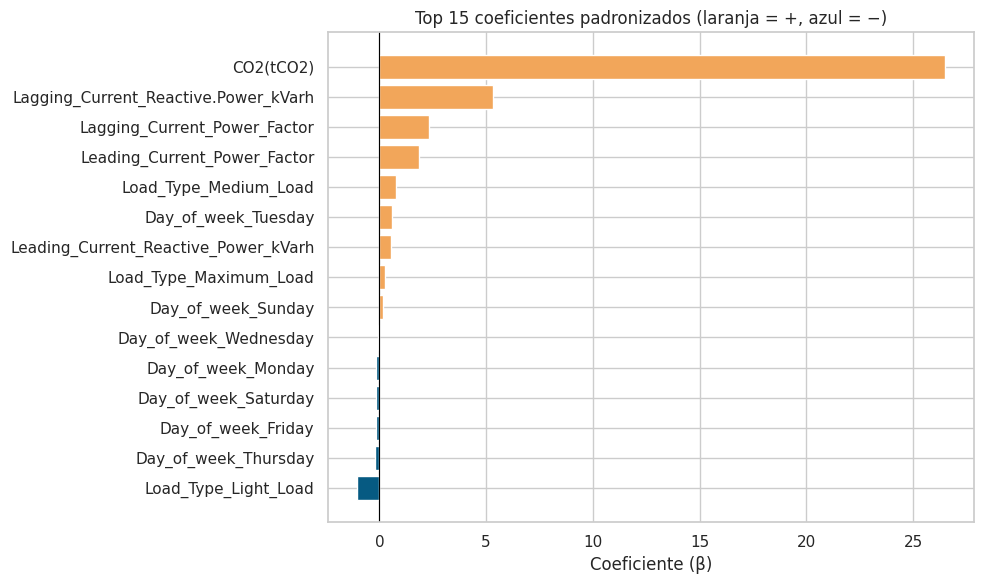

In [ ]:
# Visualização
top_n = 15
df_top = df_coef.head(top_n).sort_values("coef")

fig, ax = plt.subplots(figsize=(10, 6))
cores = [COR_ACCENT if c > 0 else COR_DEEP for c in df_top["coef"]]
ax.barh(df_top["feature"], df_top["coef"], color=cores, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Top {top_n} coeficientes padronizados (laranja = +, azul = −)")
ax.set_xlabel("Coeficiente (β)")
plt.tight_layout()
plt.show()

**Interpretação de negócio:**

- **β positivo grande** → quando a feature sobe 1 desvio-padrão, o consumo sobe β kWh.
- **β negativo grande** → relação inversa.
- **β perto de 0** → feature praticamente ignorada pelo modelo.

**⚠️ Atenção:** coeficiente alto **não significa causa**. Apenas correlação. Só um especialista de domínio confirma se faz sentido físico.

---

## Parte 11 — Exercícios

### 🎯 Desafio 1 (fácil)
Quanto o R² melhorou do modelo simples para o multivariado? Qual feature tem maior poder preditivo sozinha?

### 🎯 Desafio 2 (médio)
Crie features temporais cíclicas: `sen(2π · NSM/86400)` e `cos(2π · NSM/86400)`. Isso captura a ciclicidade do dia. Melhora o R²?

### 🎯 Desafio 3 (médio)
Troque `LinearRegression` por `Ridge(alpha=1.0)` e depois `Lasso(alpha=0.1)`. Os coeficientes mudam? O Lasso zera alguma feature?

### 🎯 Desafio 4 (Exercício 2 — entrega da semana)
Aplique o pipeline em outro dataset de regressão (ex.: [Appliances Energy Prediction](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction)) e compare as métricas.

---

## 📖 Glossário de Regressão

| Termo | Definição em 1 linha |
|---|---|
| **Regressão** | Prever valor contínuo. |
| **ŷ** | Valor previsto pelo modelo. |
| **β (beta)** | Coeficiente do modelo — peso de cada feature. |
| **Intercepto** | Valor previsto quando todas as features são zero. |
| **Resíduo** | Real − Previsto (erro em cada ponto). |
| **MAE** | Erro médio absoluto. |
| **MSE** | Erro quadrático médio. |
| **RMSE** | √MSE — na unidade original. |
| **R²** | Fração da variância explicada (0 a 1). |
| **MSE função custo** | O que o modelo minimiza no treino. |
| **Gradiente descendente** | Algoritmo de otimização passo-a-passo. |
| **Taxa de aprendizado** | Tamanho do passo do gradiente. |
| **Residuals plot** | Gráfico Resíduo × Previsto para diagnóstico. |
| **Heterocedasticidade** | Variância dos erros não é constante. |
| **Padronização** | Transformar para média 0 e desvio 1 (StandardScaler). |

---

## ✅ O que você leva deste notebook

- Intuição visual de uma regressão linear ajustada.
- Fluência em **MAE, RMSE, R²** e **residuals plot**.
- Hábito de comparar com um **baseline de 1 feature**.
- Capacidade de **interpretar coeficientes** em linguagem de negócio.

Próximo: classificação. Agora os alvos viram categorias, e as métricas mudam completamente!

*Prof. Luiz Mário · Pós-Graduação em IA e Tecnologias da Indústria 4.0*